# 1次元で実行するためのデータをつくる

In [6]:
import numpy as np
noisy = np.load("../../data/after_prep_800-1000_artificial_noisy_pe/artifical_noisy_7p5W_pe.npy")
noisy = noisy[:, :, :, 0]
print("noisy.shape", noisy.shape)

pbs = np.load("../../data/after_prep_800-1000_artificial_noisy_pe/pbs_7p5W_pe.npy")
pbs = pbs[:, :, :, 0]
print("pbs.shape", pbs.shape)

gt = np.load("../../data/after_prep_800-1000_artificial_noisy_pe/artificial_clean_7p5W.npy")
print("gt.shape", gt.shape)



noisy.shape (100, 200, 200)
pbs.shape (100, 200, 200)
gt.shape (100, 200, 200)


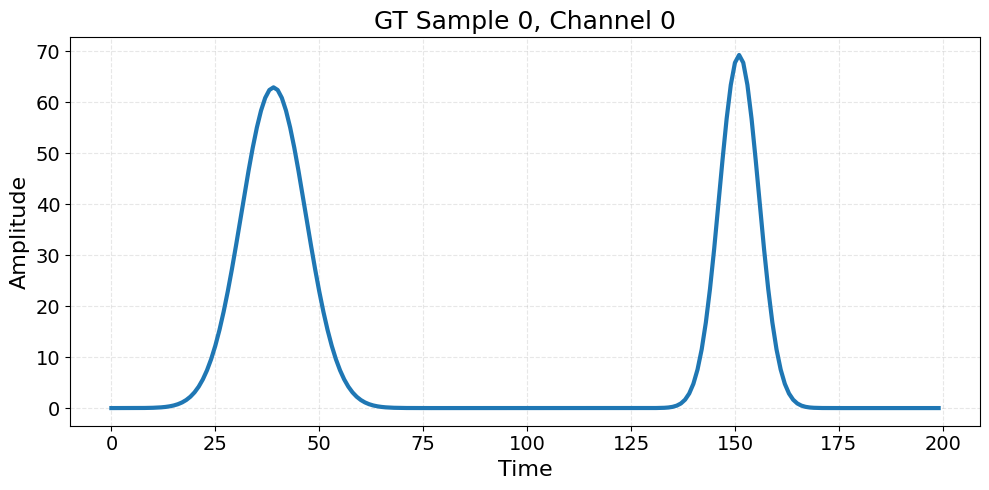

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# データ
signal = gt[1, :, 0]  # (time,)

# 横軸（時間）
time_axis = np.arange(signal.shape[0])

# プロット
plt.figure(figsize=(10, 5))
plt.plot(time_axis, signal, linewidth=3)

# ラベル
plt.xlabel("Time", fontsize=16)
plt.ylabel("Amplitude", fontsize=16)
plt.title("GT Sample 0, Channel 0", fontsize=18)

# 目盛り
plt.tick_params(axis='both', labelsize=14)

# グリッド
plt.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# shape: (N, T, C)
N, T, C = gt.shape

# 各サンプルで channel=0 の最大位置（時間）
t_max_all = np.argmax(gt[:, :, 0], axis=1)  # (N,)

# 出力配列
noisy_1d = np.zeros((N, 1, C))
pbs_1d   = np.zeros((N, 1, C))
gt_1d    = np.zeros((N, 1, C))

# 取り出し
for i in range(N):
    t = t_max_all[i]
    noisy_1d[i, 0, :] = noisy[i, t, :]
    pbs_1d[i,   0, :] = pbs[i,   t, :]
    gt_1d[i,    0, :] = gt[i,    t, :]

print("noisy_1d.shape:", noisy_1d.shape)
print("pbs_1d.shape:", pbs_1d.shape)
print("gt_1d.shape:", gt_1d.shape)

noisy_1d.shape: (100, 1, 200)
pbs_1d.shape: (100, 1, 200)
gt_1d.shape: (100, 1, 200)


/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_30128/1909686307.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


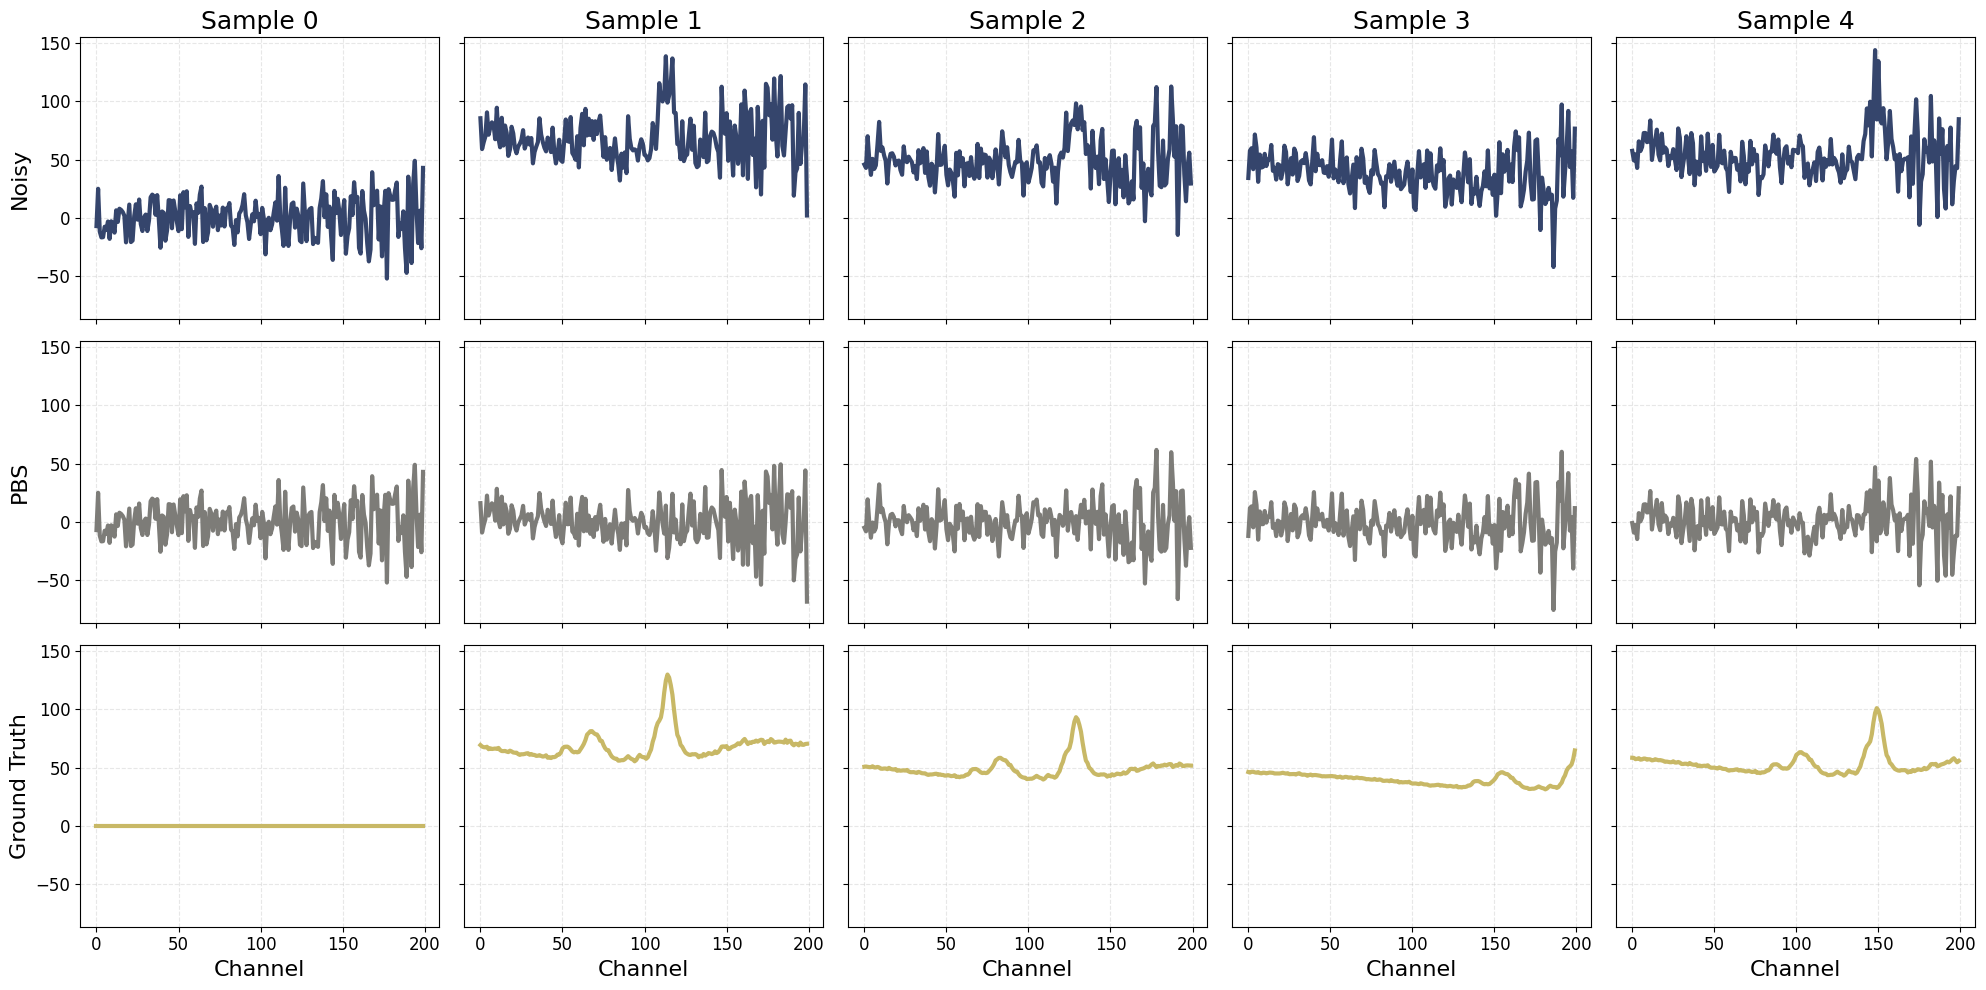

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== settings =====
samples_to_plot = 5

cmap = cm.get_cmap("cividis")
color_noisy = cmap(0.2)
color_pbs   = cmap(0.5)
color_gt    = cmap(0.8)

fontsize_title = 18
fontsize_label = 16
fontsize_tick = 12

linewidth = 3

# ===== ★ 全体のy範囲を計算 =====
all_values = []

for i in range(samples_to_plot):
    all_values.append(noisy_1d[i, 0, :])
    all_values.append(pbs_1d[i, 0, :])
    all_values.append(gt_1d[i, 0, :])

all_values = np.concatenate(all_values)

y_min = all_values.min()
y_max = all_values.max()

# 少し余白を持たせる
margin = 0.05 * (y_max - y_min)
y_min -= margin
y_max += margin

# ===== plot =====
fig, axes = plt.subplots(3, samples_to_plot, figsize=(20, 10), sharex=True, sharey=True)

row_titles = ["Noisy", "PBS", "Ground Truth"]

for i in range(samples_to_plot):

    noisy_signal = noisy_1d[i, 0, :]
    pbs_signal   = pbs_1d[i, 0, :]
    gt_signal    = gt_1d[i, 0, :]

    ch_axis = np.arange(noisy_signal.shape[0])

    axes[0, i].plot(ch_axis, noisy_signal, color=color_noisy, linewidth=linewidth)
    axes[1, i].plot(ch_axis, pbs_signal,   color=color_pbs,   linewidth=linewidth)
    axes[2, i].plot(ch_axis, gt_signal,    color=color_gt,    linewidth=linewidth)

    axes[0, i].set_title(f"Sample {i}", fontsize=fontsize_title)

    for r in range(3):
        ax = axes[r, i]

        # ★ 共通ylim
        ax.set_ylim(y_min, y_max)

        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(axis="both", labelsize=fontsize_tick)

        if i == 0:
            ax.set_ylabel(row_titles[r], fontsize=fontsize_label)

        if r == 2:
            ax.set_xlabel("Channel", fontsize=fontsize_label)

plt.tight_layout()
plt.show()

In [13]:
pwd

'/Volumes/Extreme SSD/proj-spectrum_denoising_1d/spectrum_denoising_1d/scripts'

In [ ]:
# np.save("../../data/for_1d_denoising/noisy_1d.npy", noisy_1d)
# np.save("../../data/for_1d_denoising/pbs_1d.npy", pbs_1d)
# np.save("../../data/for_1d_denoising/gt_1d.npy", gt_1d)
